# 01 — Exploratory Data Analysis & Feature Engineering
Smart Waste Management project — this notebook loads the raw simulated bin dataset, sanity-checks it,
visualizes the key relationships the models will rely on, and runs the shared feature-engineering
pipeline (`feature_engineering.py`) that Notebooks 02–04 also import.

See `ML_PIPELINE_PLAN.md` Sections 1–3 for the full reasoning behind every feature built here.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import load_raw, build_features, build_bin_aggregates

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)


## 1. Load raw data

In [2]:
df = load_raw()
print("Shape:", df.shape)
df.head()

Shape: (112574, 39)


,date,day_of_week,month,season,is_holiday,holiday_name,is_festival,festival_name,event_type,event_multiplier,zone_id,zone_name,zone_type,bin_id,latitude,longitude,bin_capacity_liters,waste_type,has_iot_sensor,population_density_per_sqkm,nearby_restaurants_count,nearby_markets_count,distance_to_nearest_bin_m,footfall_estimate,rainfall_mm,temperature_c,humidity_percent,previous_fill_percentage,previous_waste_kg,days_since_last_collection,waste_generated_kg,fill_percentage_before_collection,overflow_occurred,collection_scheduled,collection_occurred,waste_collected_kg,fill_percentage_end_of_day,target_fill_percentage_next_day,target_overflow_risk_next_day
0,2023-06-01,Thursday,6,Monsoon,False,NaN,False,NaN,none,1.00,Z01,Hampankatta,market,BIN0001,12.870784,74.842012,660,mixed,True,19391,14,4,138.9,NaN,29.4,27.6,75.0,25.61,0.00,0.0,17.50,38.24,False,True,True,53.00,2.26,16.42,0.0
1,2023-06-02,Friday,6,Monsoon,False,NaN,False,NaN,none,1.00,Z01,Hampankatta,market,BIN0001,12.870784,74.842012,660,mixed,True,19391,14,4,138.9,394.0,82.7,29.7,66.0,2.26,17.50,1.0,19.62,16.42,False,False,False,0.00,16.42,1.44,0.0
2,2023-06-03,Saturday,6,Monsoon,False,NaN,False,NaN,none,1.35,Z01,Hampankatta,market,BIN0001,12.870784,74.842012,660,mixed,True,19391,14,4,138.9,NaN,35.6,29.8,73.0,16.42,19.62,0.0,25.09,34.53,False,True,True,47.85,1.44,20.26,0.0
3,2023-06-04,Sunday,6,Monsoon,False,NaN,False,NaN,none,1.35,Z01,Hampankatta,market,BIN0001,12.870784,74.842012,660,mixed,True,19391,14,4,138.9,681.0,0.0,28.8,74.0,1.44,25.09,1.0,26.09,20.26,False,False,False,0.00,20.26,2.12,0.0
4,2023-06-05,Monday,6,Monsoon,False,NaN,False,NaN,none,1.00,Z01,Hampankatta,market,BIN0001,12.870784,74.842012,660,mixed,True,19391,14,4,138.9,329.0,161.4,29.4,76.0,20.26,26.09,0.0,18.20,33.40,False,True,True,46.29,2.12,19.03,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112574 entries, 0 to 112573
Data columns (total 39 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               112574 non-null  datetime64[ns]
 1   day_of_week                        112574 non-null  object        
 2   month                              112574 non-null  int64         
 3   season                             112574 non-null  object        
 4   is_holiday                         112574 non-null  bool          
 5   holiday_name                       2156 non-null    object        
 6   is_festival                        112574 non-null  bool          
 7   festival_name                      7546 non-null    object        
 8   event_type                         112574 non-null  object        
 9   event_multiplier                   112574 non-null  float64       
 10  zone_id             

## 2. Missing values
Missingness is intentional and structural (see `DATA_DICTIONARY.md` §3) — non-IoT bins are missing far more fill readings than IoT bins.

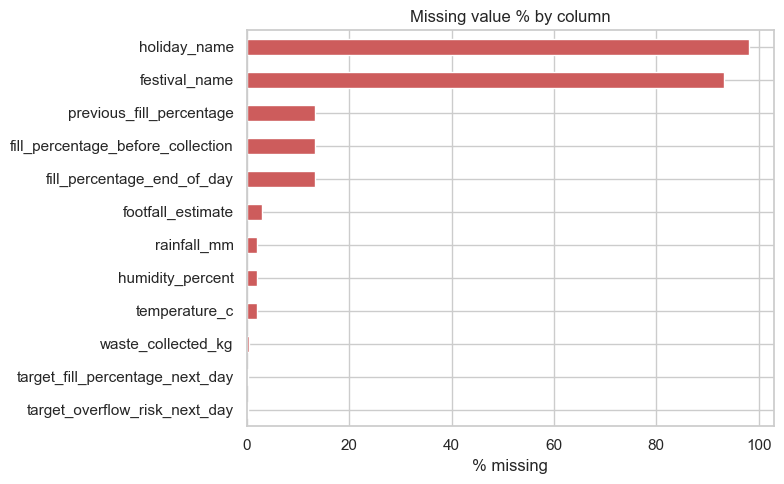

In [4]:
missing = (df.isna().mean() * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind="barh", color="indianred", figsize=(8, 5))
plt.title("Missing value % by column")
plt.xlabel("% missing")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [5]:
# Confirm the IoT-vs-non-IoT missingness gap that motivates sensor_staleness_days as a feature
missing_by_iot = df.groupby("has_iot_sensor")["fill_percentage_end_of_day"].apply(lambda s: s.isna().mean() * 100)
print("Missing fill_percentage_end_of_day (%) by IoT sensor status:")
print(missing_by_iot.round(1))

Missing fill_percentage_end_of_day (%) by IoT sensor status:
has_iot_sensor
False    37.7
True      1.5
Name: fill_percentage_end_of_day, dtype: float64


## 3. Target distributions

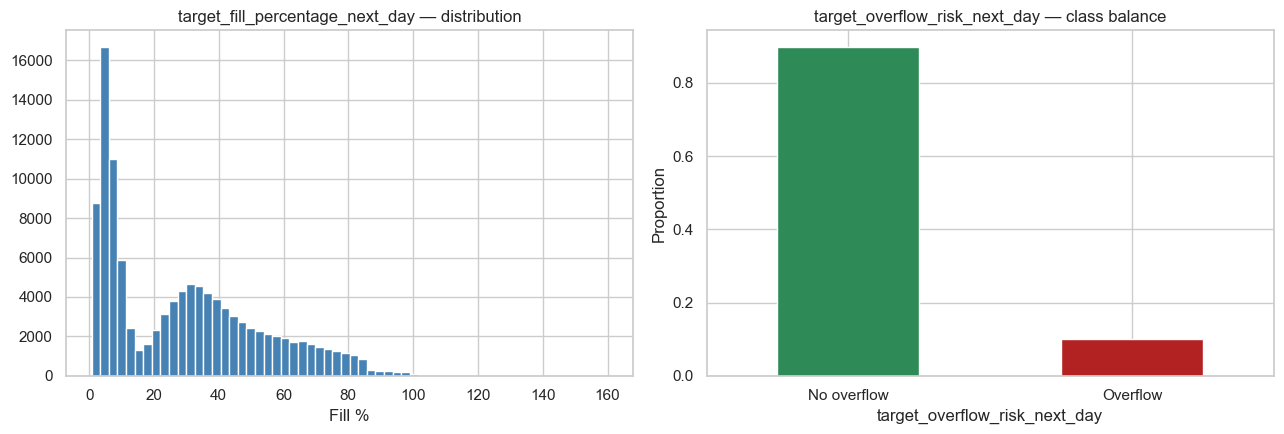

target_overflow_risk_next_day
0.0    0.898
1.0    0.102
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["target_fill_percentage_next_day"].dropna().hist(bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("target_fill_percentage_next_day — distribution")
axes[0].set_xlabel("Fill %")

df["target_overflow_risk_next_day"].dropna().value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[1], color=["seagreen", "firebrick"])
axes[1].set_title("target_overflow_risk_next_day — class balance")
axes[1].set_xticklabels(["No overflow", "Overflow"], rotation=0)
axes[1].set_ylabel("Proportion")
plt.tight_layout(); plt.show()

print(df["target_overflow_risk_next_day"].value_counts(normalize=True).round(4))

## 4. Zone-type and seasonal relationships
These are the relationships the models are expected to learn — worth confirming they exist before training anything.

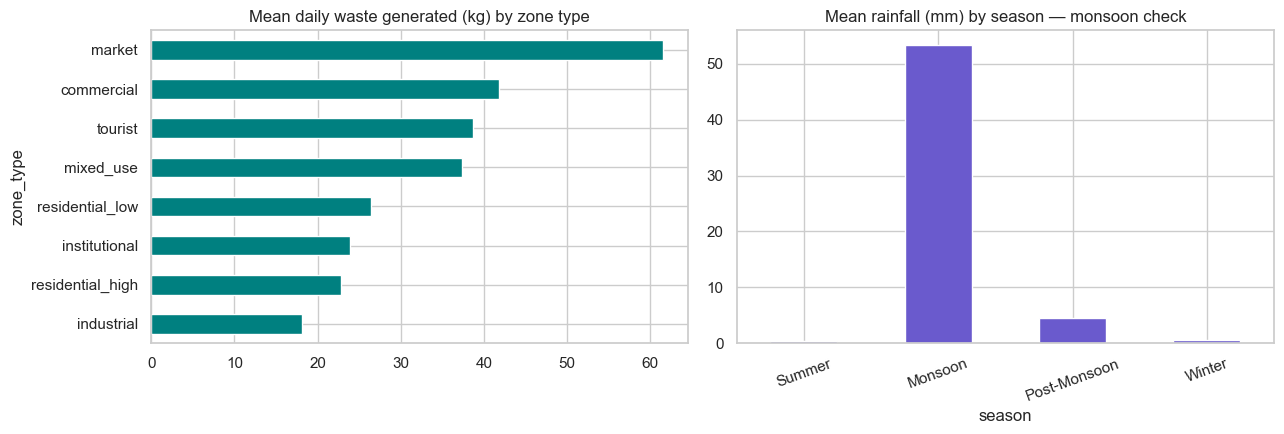

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df.groupby("zone_type")["waste_generated_kg"].mean().sort_values().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Mean daily waste generated (kg) by zone type")

df.groupby("season")["rainfall_mm"].mean().reindex(["Summer","Monsoon","Post-Monsoon","Winter"]).plot(
    kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Mean rainfall (mm) by season — monsoon check")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

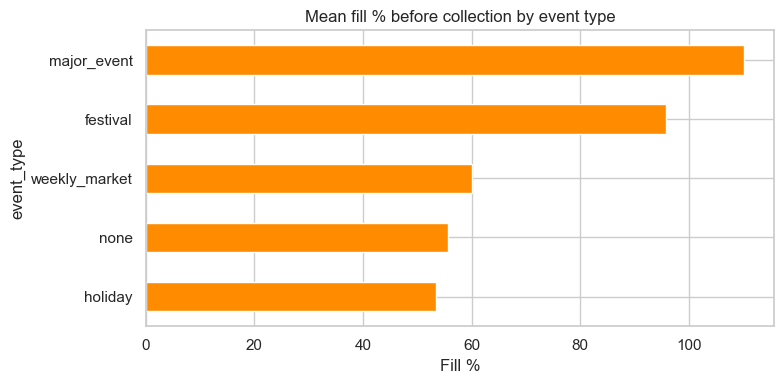

event_type
holiday           53.4
none              55.6
weekly_market     60.1
festival          95.7
major_event      110.2
Name: fill_percentage_before_collection, dtype: float64


In [8]:
event_effect = df.groupby("event_type")["fill_percentage_before_collection"].mean().sort_values()
event_effect.plot(kind="barh", color="darkorange", figsize=(8,4))
plt.title("Mean fill % before collection by event type")
plt.xlabel("Fill %")
plt.tight_layout(); plt.show()
print(event_effect.round(1))

## 5. What a single bin's time series looks like
The sawtooth pattern (fill up, get emptied, repeat) is the core structure the lag/rolling features in Section 3.1 are designed to capture.

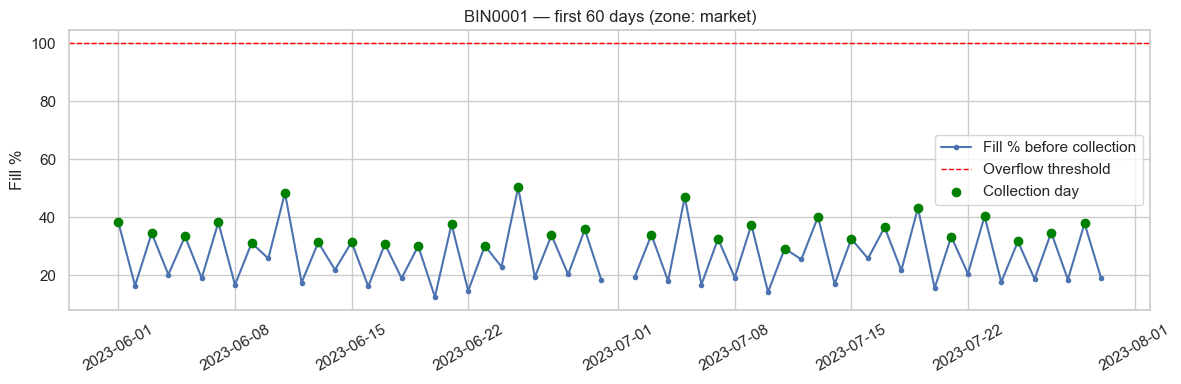

In [9]:
sample_bin = "BIN0001"
sample = df[df["bin_id"] == sample_bin].sort_values("date").head(60)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample["date"], sample["fill_percentage_before_collection"], marker="o", ms=3, label="Fill % before collection")
ax.axhline(100, color="red", ls="--", lw=1, label="Overflow threshold")
collected = sample[sample["collection_occurred"]]
ax.scatter(collected["date"], collected["fill_percentage_before_collection"], color="green", zorder=5, label="Collection day")
ax.set_title(f"{sample_bin} — first 60 days (zone: {sample['zone_type'].iloc[0]})")
ax.set_ylabel("Fill %")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 6. Correlation among key numeric drivers

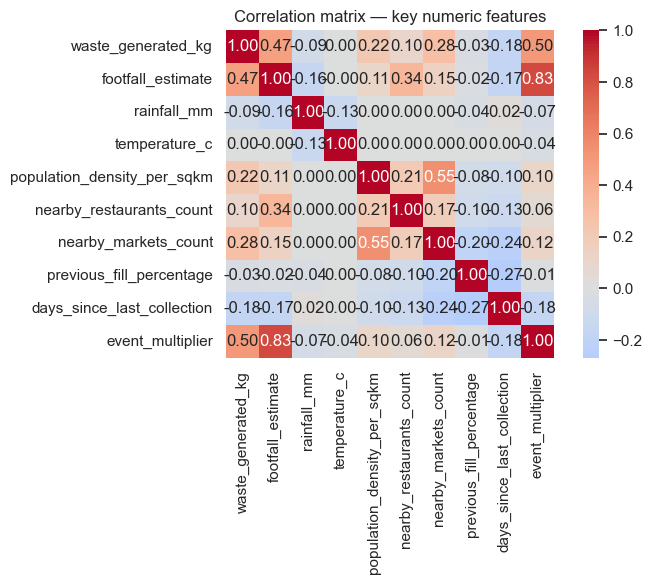

In [10]:
num_cols = ["waste_generated_kg", "footfall_estimate", "rainfall_mm", "temperature_c",
            "population_density_per_sqkm", "nearby_restaurants_count", "nearby_markets_count",
            "previous_fill_percentage", "days_since_last_collection", "event_multiplier"]
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix — key numeric features")
plt.tight_layout(); plt.show()

## 7. Run the shared feature-engineering pipeline
This is the exact function Notebooks 02–04 import — lag features, rolling stats, cyclical calendar encoding, interaction terms (see `feature_engineering.py`).

In [11]:
df_feat = build_features(df)
print("Before:", df.shape, " After feature engineering:", df_feat.shape)
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"\n{len(new_cols)} new engineered columns:")
print(new_cols)

Before: (112574, 39)  After feature engineering: (112574, 71)

32 new engineered columns:
['fill_pct_lag_1d', 'waste_kg_lag_1d', 'fill_pct_lag_2d', 'waste_kg_lag_2d', 'fill_pct_lag_3d', 'waste_kg_lag_3d', 'fill_pct_lag_7d', 'waste_kg_lag_7d', 'rolling_mean_fill_pct_3d', 'rolling_mean_fill_pct_7d', 'rolling_mean_fill_pct_14d', 'rolling_std_fill_pct_7d', 'rolling_max_fill_pct_7d', 'waste_kg_rolling_mean_7d', 'waste_kg_rolling_mean_14d', 'days_since_last_overflow', 'sensor_staleness_days', 'collection_frequency_14d', 'fill_rate_per_day', 'fill_acceleration', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'days_to_next_holiday', 'days_since_last_holiday', 'is_festival_eve', 'capacity_utilization_ratio', 'waste_per_capita_proxy', 'footfall_per_restaurant', 'rain_x_zone_outdoor']


In [12]:
df_feat[["bin_id", "date", "fill_pct_lag_1d", "rolling_mean_fill_pct_7d",
         "days_since_last_overflow", "days_to_next_holiday", "fill_rate_per_day"]].head(10)

,bin_id,date,fill_pct_lag_1d,rolling_mean_fill_pct_7d,days_since_last_overflow,days_to_next_holiday,fill_rate_per_day
0,BIN0001,2023-06-01,NaN,2.260000,999.0,75.0,NaN
1,BIN0001,2023-06-02,2.26,9.340000,999.0,74.0,14.16
2,BIN0001,2023-06-03,16.42,6.706667,999.0,73.0,-14.98
3,BIN0001,2023-06-04,1.44,10.095000,999.0,72.0,18.82
4,BIN0001,2023-06-05,20.26,8.500000,999.0,71.0,-18.14
5,BIN0001,2023-06-06,2.12,10.255000,999.0,70.0,16.91
6,BIN0001,2023-06-07,19.03,9.144286,999.0,69.0,-16.55
7,BIN0001,2023-06-08,2.48,11.212857,999.0,68.0,14.26
8,BIN0001,2023-06-09,16.74,9.240000,999.0,67.0,-14.13
9,BIN0001,2023-06-10,2.61,12.720000,999.0,66.0,23.19


## 8. Per-bin aggregates (input to the clustering notebook)

In [13]:
agg = build_bin_aggregates(df)
print(agg.shape)
agg.describe().round(2)

(154, 13)


,bin_capacity_liters,avg_fill_pct,std_fill_pct,avg_waste_kg_per_day,overflow_rate,avg_days_between_collections,festival_sensitivity,weekend_sensitivity,rain_sensitivity
count,154.00,154.00,154.00,154.00,154.00,154.0,154.00,154.00,154.00
mean,571.04,59.57,25.69,41.85,0.10,0.0,1.76,1.08,0.86
std,341.19,12.80,4.09,33.12,0.09,0.0,0.26,0.12,0.08
min,120.00,28.67,14.14,4.16,0.00,0.0,1.34,0.77,0.67
25%,240.00,50.02,22.86,16.59,0.03,0.0,1.54,1.05,0.81
50%,660.00,59.64,25.95,35.31,0.05,0.0,1.73,1.09,0.87
75%,660.00,70.33,29.26,53.77,0.17,0.0,1.97,1.12,0.92
max,1100.00,81.28,32.15,170.54,0.31,0.0,2.37,1.42,1.02


## 9. Summary
- 112,574 raw rows confirmed to have realistic seasonal, event, and zone-driven structure (not i.i.d. noise).
- Missingness is concentrated in non-IoT bins as designed — this is a feature (`sensor_staleness_days`), not just noise to drop.
- Feature pipeline expands 39 raw columns to engineered features covering lags, rolling stats, cyclical time, and domain interactions.
- **Next:** `02_model3_bin_clustering.ipynb` segments bins by behavior; its output feeds `03` and `04`.